# Pseudobulk PCA — All Human Datasets

Each of the 20 (analysis × technology) combinations is collapsed to a single pseudobulk count vector by summing across all cells. PCA is run on log-CPM normalised gene expression and the top two PCs are plotted, coloured by tissue type and labelled by analysis shorthand.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from sklearn.decomposition import PCA
from XvP_utils import plotting

%matplotlib inline

project_dir = Path("/home/mcaskey/10XvParse/")

SAMPLES = {
    "A3_H1": {"analysis": "Analysis_3", "assay_suffix": "_H1", "tissue": "PBMC"},
    "A3_H2": {"analysis": "Analysis_3", "assay_suffix": "_H2", "tissue": "PBMC"},
    "A5":    {"analysis": "Analysis_5", "assay_suffix": "",    "tissue": "Frozen PBMC"},
    "A6":    {"analysis": "Analysis_6", "assay_suffix": "",    "tissue": "Cancer"},
    "A7":    {"analysis": "Analysis_7", "assay_suffix": "",    "tissue": "Frozen PBMC"},
}
TECHNOLOGIES = {
    "10X":   {"data_name": "10x",   "assay_prefix": "10x"},
    "polyT": {"data_name": "polyT", "assay_prefix": "parse"},
    "randO": {"data_name": "randO", "assay_prefix": "parse"},
    "Parse": {"data_name": "parse", "assay_prefix": "parse"},
}

TISSUE_COLORS = {
    "PBMC":         "#1f77b4",
    "Frozen PBMC":  "#74b9ff",
    "Cancer":       "#d62728",
}
TECH_MARKERS = {
    "10X":   "o",
    "polyT": "s",
    "randO": "^",
    "Parse": "D",
}

In [6]:
records = {}
meta = []  # (col_name, label, tech, tissue)

for label, sinfo in SAMPLES.items():
    for tech, tinfo in TECHNOLOGIES.items():
        assay = tinfo["assay_prefix"] + sinfo["assay_suffix"]
        print(f"Loading {label} {tech} ({sinfo['analysis']}, assay={assay})...")
        data = plotting.init_processing(
            analysis_name=sinfo["analysis"],
            project_dir=project_dir,
            data_name=tinfo["data_name"],
            assay=assay,
            data_title=f"{label} {tech}",
        )
        col = f"{label}_{tech}"
        records[col] = pd.Series(
            np.asarray(data.X.sum(axis=0)).flatten(),
            index=data.var_names,
        )
        meta.append((col, label, tech, sinfo["tissue"]))

# Intersect to genes present in every sample, drop all-zero rows
counts = pd.DataFrame(records)
counts = counts.loc[counts.notna().all(axis=1)]
counts = counts.loc[counts.sum(axis=1) > 0]
print(f"\n{len(counts)} genes retained across {len(meta)} samples")

Loading A3_H1 10X (Analysis_3, assay=10x_H1)...
Loading A3_H1 polyT (Analysis_3, assay=parse_H1)...
Loading A3_H1 randO (Analysis_3, assay=parse_H1)...
Loading A3_H1 Parse (Analysis_3, assay=parse_H1)...
Loading A3_H2 10X (Analysis_3, assay=10x_H2)...
Loading A3_H2 polyT (Analysis_3, assay=parse_H2)...
Loading A3_H2 randO (Analysis_3, assay=parse_H2)...
Loading A3_H2 Parse (Analysis_3, assay=parse_H2)...
Loading A5 10X (Analysis_5, assay=10x)...
Loading A5 polyT (Analysis_5, assay=parse)...
Loading A5 randO (Analysis_5, assay=parse)...
Loading A5 Parse (Analysis_5, assay=parse)...
Loading A6 10X (Analysis_6, assay=10x)...
Loading A6 polyT (Analysis_6, assay=parse)...
Loading A6 randO (Analysis_6, assay=parse)...
Loading A6 Parse (Analysis_6, assay=parse)...
Loading A7 10X (Analysis_7, assay=10x)...
Loading A7 polyT (Analysis_7, assay=parse)...
Loading A7 randO (Analysis_7, assay=parse)...
Loading A7 Parse (Analysis_7, assay=parse)...

16768 genes retained across 20 samples


In [ ]:
# CPM normalise then log1p
cpm = counts.div(counts.sum(axis=0), axis=1) * 1e6
log_cpm = np.log1p(cpm)

pca = PCA(n_components=2)
coords = pca.fit_transform(log_cpm.T)  # samples × 2
var_explained = pca.explained_variance_ratio_ * 100
print(f"PC1: {var_explained[0]:.1f}%   PC2: {var_explained[1]:.1f}%")

PC1: 39.4%   PC2: 28.7%


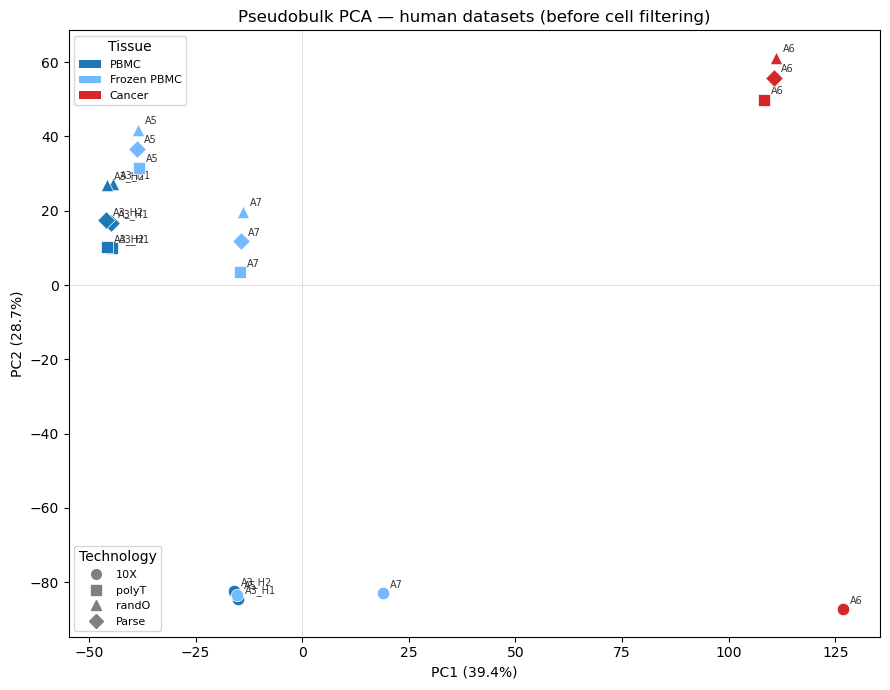

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

for i, (col, label, tech, tissue) in enumerate(meta):
    ax.scatter(
        coords[i, 0], coords[i, 1],
        color=TISSUE_COLORS[tissue],
        marker=TECH_MARKERS[tech],
        s=80, zorder=3, linewidths=0.5, edgecolors="white",
    )
    ax.annotate(
        label,
        (coords[i, 0], coords[i, 1]),
        textcoords="offset points", xytext=(5, 4),
        fontsize=7, color="#333333",
    )

ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}%)")
ax.set_title("Pseudobulk PCA — human datasets (before cell filtering)")
ax.axhline(0, color="lightgrey", linewidth=0.5, zorder=0)
ax.axvline(0, color="lightgrey", linewidth=0.5, zorder=0)

tissue_handles = [
    mpatches.Patch(facecolor=c, label=t) for t, c in TISSUE_COLORS.items()
]
tech_handles = [
    mlines.Line2D([], [], color="grey", marker=m, linestyle="None", markersize=7, label=t)
    for t, m in TECH_MARKERS.items()
]
legend1 = ax.legend(handles=tissue_handles, title="Tissue", loc="upper left", fontsize=8)
ax.add_artist(legend1)
ax.legend(handles=tech_handles, title="Technology", loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()